Table of contents
* 1. Pre-processing
   * 1.1 Import packages
   * 1.2 Set up Data Augmentation
   * 1.3 Split into Training & Testing sets
<br>
<br>
* 2. Modeling
    * 2.1 ResNet Model
    * 2.2 EfficientNet Model- Basic
    * 2.3 EfficientNet Model- Tuning
<br>
<br>
* 3. Calibration and Threshold Tuning 
   * 3.1 Temperature Scaling
   * 3.2 Threshold Tuning
   * 3.3 Sample Predictions
<br>
<br>
* 4. Analyzing results 

# 1. Pre-processing

1.1 Import packages

In [1]:
# Import packages
import os
import pandas as pd
import numpy as np

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets, models
import torch.optim as optim
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import confusion_matrix, precision_score, recall_score, fbeta_score
import time
import random

In [ ]:
#Set up Reproducibility 
SEED = 42

#Set seeds
random.seed(SEED)
numpy.random.seed(SEED)
torch.manual_seed(SEED)

#Force deterministic operations in PyTorch
torch.use_deterministic_algorithms(True)

#Make Python hashing deterministic
os.environ["PYTHONHASHSEED"] = str(SEED)

Control CPU thread parallelism 
torch.set_num_threads(2)            
torch.set_num_interop_threads(2)

#DataLoader worker seeding
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)



In [2]:
#setup directory
data_dir = "./tpc-imgs"

1.2 Set up Data Augmentation

In [3]:
IMG_SIZE = 224

# Data Augmentation for training set

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomApply([transforms.RandomAffine(0, shear=2)], p=0.15),
    transforms.RandomApply([transforms.RandomPerspective(distortion_scale=0.05)], p=0.10),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])


])

# Data Augmentation for testing set
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


1.3 Split into Training & Testing sets

In [4]:
# Load full dataset
full_dataset = datasets.ImageFolder(root=data_dir)

# Split indices
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# setup DataLoaders
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, worker_init_fn=seed_worker, generator=g)

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Modeling

2.1 ResNet Model

In [5]:
# Setup resnet model
modelR = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in modelR.parameters():
    param.requires_grad = False

# Replace classifier head
num_features = modelR.fc.in_features
modelR.fc = nn.Linear(num_features, 2)

modelR.to(device)

# Set Criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelR.fc.parameters(), lr=1e-4)


In [6]:
# Run resnet model
epochs = 5 #initially ran 15 but switched to 5 for rerun to cut down on time

total_start = time.time()

for epoch in range(epochs):
    epoch_start = time.time()
    modelR.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelR(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # Validation
    modelR.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelR(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    cm = confusion_matrix(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f2 = fbeta_score(all_labels, all_preds, beta=2)

    accuracy = (all_preds == all_labels).mean()

    print(f"Validation Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    # Timing summary for this epoch
    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start
    remaining = (total_time / (epoch + 1)) * (epochs - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

Epoch 1/5 - Loss: 0.7118
Validation Accuracy: 0.5595
Confusion Matrix:
 [[420 603]
 [274 694]]
Recall:    0.7169
Precision: 0.5351
F2 Score:  0.6713
Epoch Time: 4.25 min | Total Elapsed: 4.25 min | Est. Remaining: 17.01 min
--------------------------------------------------
Epoch 2/5 - Loss: 0.6536
Validation Accuracy: 0.6218
Confusion Matrix:
 [[511 512]
 [241 727]]
Recall:    0.7510
Precision: 0.5868
F2 Score:  0.7112
Epoch Time: 4.42 min | Total Elapsed: 8.67 min | Est. Remaining: 13.01 min
--------------------------------------------------
Epoch 3/5 - Loss: 0.6225
Validation Accuracy: 0.6715
Confusion Matrix:
 [[623 400]
 [254 714]]
Recall:    0.7376
Precision: 0.6409
F2 Score:  0.7160
Epoch Time: 5.39 min | Total Elapsed: 14.06 min | Est. Remaining: 9.37 min
--------------------------------------------------
Epoch 4/5 - Loss: 0.6015
Validation Accuracy: 0.6871
Confusion Matrix:
 [[644 379]
 [244 724]]
Recall:    0.7479
Precision: 0.6564
F2 Score:  0.7276
Epoch Time: 4.58 min | Tot

2.2 EfficientNet Model- Basic

In [7]:
# Setup efficientnet model
modelE = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in modelE.parameters():
    param.requires_grad = False

# Replace classifier
num_features = modelE.classifier[1].in_features
modelE.classifier[1] = nn.Linear(num_features, 2)

modelE.to(device)

# Set Criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE.classifier[1].parameters(), lr=1e-4)

In [8]:
#Run efficientnet model
total_start = time.time()

for epoch in range(5): #Initially ran 15 but switched to 5 for rerun to cut down on time
    epoch_start = time.time()
    modelE.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelE(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # Validation
    modelE.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelE(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    cm = confusion_matrix(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f2 = fbeta_score(all_labels, all_preds, beta=2)

    accuracy = (all_preds == all_labels).mean()

    print(f"Validation Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    # Timing summary for this epoch
    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start
    remaining = (total_time / (epoch + 1)) * (epochs - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

Epoch 1/5 - Loss: 0.6728
Validation Accuracy: 0.6519
Confusion Matrix:
 [[624 399]
 [294 674]]
Recall:    0.6963
Precision: 0.6281
F2 Score:  0.6815
Epoch Time: 4.51 min | Total Elapsed: 4.51 min | Est. Remaining: 18.05 min
--------------------------------------------------
Epoch 2/5 - Loss: 0.6323
Validation Accuracy: 0.6856
Confusion Matrix:
 [[765 258]
 [368 600]]
Recall:    0.6198
Precision: 0.6993
F2 Score:  0.6342
Epoch Time: 4.38 min | Total Elapsed: 8.89 min | Est. Remaining: 13.34 min
--------------------------------------------------
Epoch 3/5 - Loss: 0.6060
Validation Accuracy: 0.7022
Confusion Matrix:
 [[783 240]
 [353 615]]
Recall:    0.6353
Precision: 0.7193
F2 Score:  0.6505
Epoch Time: 4.49 min | Total Elapsed: 13.38 min | Est. Remaining: 8.92 min
--------------------------------------------------
Epoch 4/5 - Loss: 0.5913
Validation Accuracy: 0.7207
Confusion Matrix:
 [[731 292]
 [264 704]]
Recall:    0.7273
Precision: 0.7068
F2 Score:  0.7231
Epoch Time: 4.29 min | Tot

2.3 EfficientNet Model- Tuning

In [9]:
# Create Functions for use in tuning better efficientNet Model

def mixup_data(x, y, alpha=0.4):
    """ Perform Mixup augmentation on a batch of images and labels."""
    
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    return mixed_x, y, y[index], lam


def cutmix_data(x, y, alpha=0.4):
    """ Perform CutMix augmentation on a batch of images and labels."""
    
    lam = np.random.beta(alpha, alpha)
    batch_size, _, h, w = x.size()
    index = torch.randperm(batch_size).to(x.device)

    cut_w = int(w * np.sqrt(1 - lam))
    cut_h = int(h * np.sqrt(1 - lam))

    cx = np.random.randint(w)
    cy = np.random.randint(h)

    x1 = np.clip(cx - cut_w // 2, 0, w)
    x2 = np.clip(cx + cut_w // 2, 0, w)
    y1 = np.clip(cy - cut_h // 2, 0, h)
    y2 = np.clip(cy + cut_h // 2, 0, h)

    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]

    lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    return x, y, y[index], lam


def mixup_cutmix_criterion(criterion, preds, y_a, y_b, lam):
    """Compute the loss for Mixup or CutMix augmented samples."""
    
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)


def compute_metrics(model, dataloader, device, toxic_class=1):
    """Compute confusion matrix, precision, recall, and F2 score for a model.
       Runs the model on the provided dataloader and collects predictions and labels to compute classification metrics."""
    
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, pos_label=toxic_class)
    precision = precision_score(all_labels, all_preds, pos_label=toxic_class)
    f2 = fbeta_score(all_labels, all_preds, beta=2, pos_label=toxic_class)

    return cm, precision, recall, f2


# Training Loop
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    """Train the model for a single epoch with optional Mixup/CutMix augmentation.
       Randomly applies Mixup or CutMix to each batch with equal probability.
       Computes loss, performs backpropagation, and tracks accuracy."""
    
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        rand_val = np.random.rand()

        if rand_val < 0.25:
            images_mixed, y_a, y_b, lam = mixup_data(images, labels)
            outputs = model(images_mixed)
            loss = mixup_cutmix_criterion(criterion, outputs, y_a, y_b, lam)

        elif rand_val < 0.50:
            images_mixed, y_a, y_b, lam = cutmix_data(images, labels)
            outputs = model(images_mixed)
            loss = mixup_cutmix_criterion(criterion, outputs, y_a, y_b, lam)

        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


# Validation Loop
def validate(model, dataloader, criterion, device):
    """Evaluate the model on a validation dataset.
       Computes loss and accuracy without performing gradient updates."""
    
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [10]:
# Setup efficientnet model
modelE2 = models.efficientnet_b0(weights="IMAGENET1K_V1")
num_features = modelE2.classifier[1].in_features
modelE2.classifier[1] = nn.Linear(num_features, len(full_dataset.classes))

modelE2 = modelE2.to(device)

# Set Criterion
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.3]).to(device), label_smoothing=0.05)


In [11]:
# Run EfficientNet Model
# Phase 1 - Train classifier Head
for param in modelE2.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(modelE2.classifier[1].parameters(), lr=2e-4)

def warmup(epoch):
    """Linear warmup schedule for learning rate scaling.
       Gradually increases the learning rate during the first few epochs
       to stabilize early training."""
    
    return min(1.0, (epoch + 1) / 3)

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=3, eta_min=1e-6)

print("=== Phase 1: Training classifier head ===")
phase1_start = time.time()
for epoch in range(6):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch(modelE2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE2, val_loader, criterion, device)

    if epoch < 3:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE2, val_loader, device)

    print(f"\nEpoch {epoch+1}/6 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    epoch_time = time.time() - epoch_start
    total_time = time.time() - phase1_start
    remaining = (total_time / (epoch + 1)) * (6 - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

print(f"=== Phase 1 Complete | Total Time: {(time.time() - phase1_start)/60:.2f} min ===")

# Phase 2 - Unfreeze Top 30%
for name, param in modelE2.named_parameters():
    if "blocks.5" in name or "blocks.6" in name:
        param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, modelE2.parameters()), lr=3e-5)
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e+1)/2))
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=2, eta_min=1e-6)

print("\n=== Phase 2: Unfreezing top layers ===")
phase2_start = time.time()

for epoch in range(4):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch(modelE2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE2, val_loader, criterion, device)

    if epoch < 2:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE2, val_loader, device)

    print(f"\nEpoch {epoch+1}/4 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    epoch_time = time.time() - epoch_start
    total_time = time.time() - phase2_start
    remaining = (total_time / (epoch + 1)) * (4 - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

print(f"=== Phase 2 Complete | Total Time: {(time.time() - phase2_start)/60:.2f} min ===")

# Phase 3 - Full Fine Tune
for param in modelE2.parameters():
    param.requires_grad = True

optimizer = optim.Adam(modelE2.parameters(), lr=1e-5)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=5e-6)

print("\n=== Phase 3: Full fine-tuning ===")
phase3_start = time.time()

for epoch in range(10):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch(modelE2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE2, val_loader, criterion, device)

    cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE2, val_loader, device)

    print(f"\nEpoch {epoch+1}/10 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    epoch_time = time.time() - epoch_start
    total_time = time.time() - phase3_start
    remaining = (total_time / (epoch + 1)) * (10 - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

print(f"=== Phase 3 Complete | Total Time: {(time.time() - phase3_start)/60:.2f} min ===")

=== Phase 1: Training classifier head ===

Epoch 1/6 | Train Acc: 0.5494 | Val Acc: 0.5871
Confusion Matrix:
 [[352 671]
 [151 817]]
Recall:    0.8440
Precision: 0.5491
F2 Score:  0.7621
Epoch Time: 5.30 min | Total Elapsed: 5.30 min | Est. Remaining: 26.51 min
--------------------------------------------------

Epoch 2/6 | Train Acc: 0.5887 | Val Acc: 0.6775
Confusion Matrix:
 [[584 439]
 [203 765]]
Recall:    0.7903
Precision: 0.6354
F2 Score:  0.7535
Epoch Time: 5.30 min | Total Elapsed: 10.60 min | Est. Remaining: 21.20 min
--------------------------------------------------

Epoch 3/6 | Train Acc: 0.6445 | Val Acc: 0.7017
Confusion Matrix:
 [[615 408]
 [186 782]]
Recall:    0.8079
Precision: 0.6571
F2 Score:  0.7724
Epoch Time: 5.14 min | Total Elapsed: 15.74 min | Est. Remaining: 15.74 min
--------------------------------------------------

Epoch 4/6 | Train Acc: 0.6480 | Val Acc: 0.7097
Confusion Matrix:
 [[698 325]
 [253 715]]
Recall:    0.7386
Precision: 0.6875
F2 Score:  0.727

In [12]:
torch.save(modelE2.state_dict(), "model_final.pth")
print("Saved model to model_final.pth")

Saved model to model_final.pth


# 3. Calibration and Threshold Tuning

3.1 Temperature Scaling

In [13]:
%%time
# Model calibration using temperature scaling

class ModelWithTemperature(nn.Module):
    """Wrapper module that adds a learnable temperature parameter for post-training calibration.
       Temperature scaling adjusts the confidence of logits without changing the model's predicted class ordering."""
    
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature


def calibrate_temperature(model, dataloader, device):
    """Fit a temperature parameter to calibrate model confidence.
       Uses validation logits and labels to optimize temperature."""
    
    model.eval()
    nll_criterion = nn.CrossEntropyLoss()

    logits_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            logits_list.append(logits)
            labels_list.append(labels)

    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    temp_model = ModelWithTemperature(model).to(device)
    optimizer = optim.LBFGS([temp_model.temperature], lr=0.01, max_iter=50)

    def eval_closure():
        optimizer.zero_grad()
        loss = nll_criterion(logits / temp_model.temperature, labels)
        loss.backward()
        return loss

    optimizer.step(eval_closure)
    return temp_model

print("\n=== Calibrating model with temperature scaling ===")
modelE2 = calibrate_temperature(modelE2, val_loader, device)
print("Learned temperature:", modelE2.temperature.item())


# Threshold tuning on calibrated model
def tune_threshold(model, dataloader, device, toxic_class=1):
    """Find the optimal classification threshold based on F2 score.
       Sweeps thresholds from 0.10 to 0.90 and selects the one that maximizes the F2 score, which emphasizes recall."""
    
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)[:, toxic_class]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = torch.tensor(all_probs).numpy()
    all_labels = torch.tensor(all_labels).numpy()

    best_t, best_f2, best_recall = 0.5, -1.0, -1.0
    for t in [i / 100 for i in range(10, 91, 2)]:  # 0.10 to 0.90 step 0.02
        preds = (all_probs >= t).astype(int)
        recall = recall_score(all_labels, preds, pos_label=toxic_class)
        f2 = fbeta_score(all_labels, preds, beta=2, pos_label=toxic_class)
        if f2 > best_f2:
            best_f2, best_t, best_recall = f2, t, recall

    return best_t, best_f2, best_recall

best_t, best_f2, best_recall = tune_threshold(modelE2, val_loader, device)
print(f"\n=== Threshold tuning (calibrated model) ===")
print(f"Best threshold: {best_t:.2f}")
print(f"Best F2:        {best_f2:.4f}")
print(f"Recall at best: {best_recall:.4f}")




=== Calibrating model with temperature scaling ===
Learned temperature: 0.8025915026664734

=== Threshold tuning (calibrated model) ===
Best threshold: 0.28
Best F2:        0.9019
Recall at best: 0.9669
CPU times: total: 8min 28s
Wall time: 1min 37s


In [14]:
with open("temperature.txt", "w") as f:
    f.write(str(modelE2.temperature.item()))
print("Saved temperature to temperature.txt")


Saved temperature to temperature.txt


In [15]:
%%time
#load model to apply calibration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ModelWithTemperature(nn.Module):
    """Wrapper module that adds the fixed learned temperature parameter above"""
    def __init__(self, model, temperature):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.tensor([temperature]))

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature



# Load Trained model and apply calibration

# Load EfficientNet-B0 architecture
model = models.efficientnet_b0(weights=None)

# Replace classifier head
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)   # toxic vs clean

# Load trained weights
model.load_state_dict(torch.load("model_final.pth", map_location=device))

# Wrap with temperature scaling
temperature = modelE2.temperature.item()
model = ModelWithTemperature(model, temperature).to(device)
model.eval()


# Preprocessing Pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
])


CPU times: total: 250 ms
Wall time: 178 ms


3.2 Threshold Tuning

In [16]:
def collect_logits_and_labels(model, dataloader, device):
    """Run model to return logits + labels."""
    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_labels.append(labels)

    return torch.cat(all_logits), torch.cat(all_labels)

def compute_threshold_metrics(logits, labels, thresholds):
    """Compute precision, recall, and F2 for a list of thresholds."""
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    labels = labels.numpy()

    precisions, recalls, f2_scores = [], [], []

    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(labels, preds, zero_division=0))
        recalls.append(recall_score(labels, preds))
        f2_scores.append(fbeta_score(labels, preds, beta=2))

    return precisions, recalls, f2_scores

In [17]:
%%time
import matplotlib.pyplot as plt

# 1. Collect logits once
logits, labels = collect_logits_and_labels(modelE2, val_loader, device)

# 2. Apply temperature scaling
T = modelE2.temperature.item()
logits_eval = logits / T
#logits_eval = logits #use this variable to test model without applying temperature scaling

# 3. Define thresholds for plotting
thresholds_plot = np.linspace(0.05, 0.95, 37)

# 4. Compute metrics for plot
precisions, recalls, f2_scores = compute_threshold_metrics(
    logits_eval, labels, thresholds_plot)


CPU times: total: 4min 16s
Wall time: 49.5 s


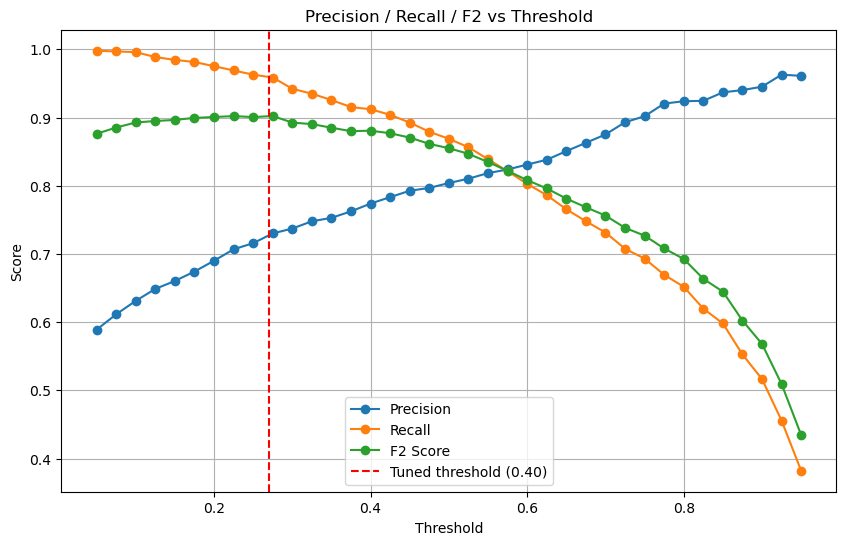

In [47]:
# 5. Plot metrics
plt.figure(figsize=(10,6))
plt.plot(thresholds_plot, precisions, label="Precision", marker="o")
plt.plot(thresholds_plot, recalls, label="Recall", marker="o")
plt.plot(thresholds_plot, f2_scores, label="F2 Score", marker="o")

plt.axvline(0.27, color="red", linestyle="--", label="Tuned threshold (0.40)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F2 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
best_idx = np.argmax(f2_scores)
print(f"Best F2 threshold: {thresholds_plot[best_idx]:.2f} | F2={f2_scores[best_idx]:.4f}")

# Find thresholds where precision >= 0.70 AND recall >= 0.90
candidates = [
    (t, p, r) for t, p, r in zip(thresholds_plot, precisions, recalls)
    if p >= 0.7000 and r >= 0.8999
]

if candidates:
    print("\nBalanced thresholds (precision ≥ 0.7000 and recall ≥ 0.9000):")
    for t, p, r in candidates:
        print(f"Threshold {t:.2f} | Recall={r:.4f} | Precision={p:.4f}")
else:
    print("\nNo threshold meets precision ≥ 0.7000 and recall ≥ 0.9000 simultaneously.")

Best F2 threshold: 0.27 | F2=0.9022

Balanced thresholds (precision ≥ 0.7000 and recall ≥ 0.9000):
Threshold 0.22 | Recall=0.9690 | Precision=0.7069
Threshold 0.25 | Recall=0.9628 | Precision=0.7158
Threshold 0.27 | Recall=0.9587 | Precision=0.7301
Threshold 0.30 | Recall=0.9421 | Precision=0.7373
Threshold 0.32 | Recall=0.9349 | Precision=0.7479
Threshold 0.35 | Recall=0.9256 | Precision=0.7529
Threshold 0.37 | Recall=0.9153 | Precision=0.7625
Threshold 0.40 | Recall=0.9122 | Precision=0.7739
Threshold 0.42 | Recall=0.9039 | Precision=0.7833


In [31]:
# Loop through thresholds .20 - .50 to receive metrics

thresholds_zoom = [round(t, 2) for t in np.arange(0.20, 0.50, 0.02)]

probs = torch.softmax(logits_eval, dim=1)[:, 1].numpy()
labels_np = labels.numpy()

for th in thresholds_zoom:
    preds = (probs >= th).astype(int)

    cm = confusion_matrix(labels_np, preds)
    precision = precision_score(labels_np, preds, zero_division=0)
    recall = recall_score(labels_np, preds)
    f2 = fbeta_score(labels_np, preds, beta=2)

    print(f"Threshold: {th:.2f}")
    print("Confusion Matrix:\n", cm)
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F2: {f2:.4f}")
    print("-" * 40)


Threshold: 0.20
Confusion Matrix:
 [[599 424]
 [ 24 944]]
Precision: 0.6901 | Recall: 0.9752 | F2: 0.9008
----------------------------------------
Threshold: 0.22
Confusion Matrix:
 [[625 398]
 [ 29 939]]
Precision: 0.7023 | Recall: 0.9700 | F2: 0.9013
----------------------------------------
Threshold: 0.24
Confusion Matrix:
 [[645 378]
 [ 33 935]]
Precision: 0.7121 | Recall: 0.9659 | F2: 0.9016
----------------------------------------
Threshold: 0.26
Confusion Matrix:
 [[664 359]
 [ 37 931]]
Precision: 0.7217 | Recall: 0.9618 | F2: 0.9018
----------------------------------------
Threshold: 0.28
Confusion Matrix:
 [[683 340]
 [ 41 927]]
Precision: 0.7316 | Recall: 0.9576 | F2: 0.9019
----------------------------------------
Threshold: 0.30
Confusion Matrix:
 [[698 325]
 [ 56 912]]
Precision: 0.7373 | Recall: 0.9421 | F2: 0.8925
----------------------------------------
Threshold: 0.32
Confusion Matrix:
 [[717 306]
 [ 62 906]]
Precision: 0.7475 | Recall: 0.9360 | F2: 0.8910
------------

3.3 Sample Predictions

In [49]:
# function to predict image toxicity

THRESHOLD = 0.28   # tuned threshold (picked for recall above 95%, f2 above 90%, Presision above 70% and FN below 50)

def predict_image(image_path):
    """Predict toxicity for a single image using the tuned threshold."""
    
    img = Image.open(image_path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

    toxic_prob = probs[1].item()
    prediction = 1 if toxic_prob >= THRESHOLD else 0

    return {
        "prediction": "TOXIC" if prediction == 1 else "Non-Toxic",
        "toxic_probability": toxic_prob,
        "threshold_used": THRESHOLD
    }

In [34]:
# Test example
result = predict_image("tpc-imgs\\nontoxic_images\\003\\345.jpg")
print(result)


{'prediction': 'Non-Toxic', 'toxic_probability': 0.01253040973097086, 'threshold_used': 0.35}


In [50]:
%%time
# function to batch predict image toxicity for a single folder

THRESHOLD = 0.28  # tuned threshold (picked for recall above 95%, f2 above 90%, Presision above 70% and FN below 50)

def predict_folder(folder_path, save_toxic=False):
    """Predict toxicity for a each image in a folder using the tuned threshold."""
    results = []
    toxic_dir = os.path.join(folder_path, "toxic_detected")

    if save_toxic and not os.path.exists(toxic_dir):
        os.makedirs(toxic_dir)

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            continue

        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path).convert("RGB")
        x = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0]

        toxic_prob = probs[1].item()
        prediction = 1 if toxic_prob >= THRESHOLD else 0
        label = "TOXIC" if prediction == 1 else "Non-Toxic"

        # Save toxic images if requested
        if save_toxic and prediction == 1:
            img.save(os.path.join(toxic_dir, filename))

        results.append({
            "filename": filename,
            "prediction": label,
            "toxic_probability": toxic_prob,
            "threshold": THRESHOLD
        })

    return pd.DataFrame(results)

CPU times: total: 0 ns
Wall time: 0 ns


In [36]:
#Create list of toxic folders
folders_toxic = [
    "tpc-imgs/toxic_images/000",
    "tpc-imgs/toxic_images/001",
    "tpc-imgs/toxic_images/002",
    "tpc-imgs/toxic_images/003",
    "tpc-imgs/toxic_images/004"
]

In [51]:
%%time
#loop through all five toxic folders
toxic_results = []

for folder in folders_toxic:
    df_toxic = predict_folder(folder, save_toxic=False)
    df_toxic["source_folder"] = folder  # track where each image came from
    toxic_results.append(df_toxic)


CPU times: total: 23min 34s
Wall time: 4min 35s


In [52]:
# Create a dataframe with the results and save as a csv file
df_toxic_final = pd.concat(toxic_results, ignore_index=True)
df_toxic_final.to_csv("Toxic_predictions_all_folders.csv", index=False)

print("Saved results to Toxic_predictions_all_folders.csv")


Saved results to Toxic_predictions_all_folders.csv


In [59]:
df_toxic_final.prediction.value_counts()

prediction
TOXIC        4878
Non-Toxic      75
Name: count, dtype: int64

In [54]:
#Create list of non-toxic folders
folders_nontoxic = [
    "tpc-imgs/nontoxic_images/000",
    "tpc-imgs/nontoxic_images/001",
    "tpc-imgs/nontoxic_images/002",
    "tpc-imgs/nontoxic_images/003",
    "tpc-imgs/nontoxic_images/004"
]

In [55]:
%%time
#loop through all five non-toxic folders
nontoxic_results = []

for folder in folders_nontoxic:
    df_nontoxic = predict_folder(folder, save_toxic=False)
    df_nontoxic["source_folder"] = folder  # track where each image came from
    nontoxic_results.append(df_nontoxic)

CPU times: total: 29min 9s
Wall time: 5min 20s


In [56]:
# Create a dataframe with the results and save as a csv file
df_nontoxic_final = pd.concat(nontoxic_results, ignore_index=True)
df_nontoxic_final.to_csv("NonToxic_predictions_all_folders.csv", index=False)

print("Saved results to NonToxic_predictions_all_folders.csv")

Saved results to NonToxic_predictions_all_folders.csv


In [57]:
df_nontoxic_final.prediction.value_counts()

prediction
Non-Toxic    3447
TOXIC        1552
Name: count, dtype: int64

In [21]:
# def evaluate_single_threshold(logits_eval, labels, threshold):
#     """Compute confusion matrix, precision, recall, and F2 for a single threshold."""
#     probs = torch.softmax(logits_eval, dim=1)[:, 1].numpy()
#     labels_np = labels.numpy()

#     preds = (probs >= threshold).astype(int)

#     cm = confusion_matrix(labels_np, preds)
#     precision = precision_score(labels_np, preds, zero_division=0)
#     recall = recall_score(labels_np, preds)
#     f2 = fbeta_score(labels_np, preds, beta=2)

#     print(f"Threshold: {threshold:.2f}")
#     print("Confusion Matrix:\n", cm)
#     print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F2: {f2:.4f}")
#     print("-" * 40)

#     return cm, precision, recall, f2


In [48]:
# evaluate_single_threshold(logits_eval, labels, 0.25)
# evaluate_single_threshold(logits_eval, labels, 0.26)
# evaluate_single_threshold(logits_eval, labels, 0.27)
# evaluate_single_threshold(logits_eval, labels, 0.28)
# evaluate_single_threshold(logits_eval, labels, 0.29)

Threshold: 0.25
Confusion Matrix:
 [[653 370]
 [ 36 932]]
Precision: 0.7158 | Recall: 0.9628 | F2: 0.9007
----------------------------------------
Threshold: 0.26
Confusion Matrix:
 [[664 359]
 [ 37 931]]
Precision: 0.7217 | Recall: 0.9618 | F2: 0.9018
----------------------------------------
Threshold: 0.27
Confusion Matrix:
 [[675 348]
 [ 39 929]]
Precision: 0.7275 | Recall: 0.9597 | F2: 0.9021
----------------------------------------
Threshold: 0.28
Confusion Matrix:
 [[683 340]
 [ 41 927]]
Precision: 0.7316 | Recall: 0.9576 | F2: 0.9019
----------------------------------------
Threshold: 0.29
Confusion Matrix:
 [[689 334]
 [ 49 919]]
Precision: 0.7334 | Recall: 0.9494 | F2: 0.8966
----------------------------------------


(array([[689, 334],
        [ 49, 919]], dtype=int64),
 0.7334397446129289,
 0.9493801652892562,
 0.8965853658536586)

In [58]:
df_nontoxic_final.head()

,filename,prediction,toxic_probability,threshold,source_folder
0,000.jpg,Non-Toxic,0.085745,0.28,tpc-imgs/nontoxic_images/000
1,001.jpg,TOXIC,0.323895,0.28,tpc-imgs/nontoxic_images/000
2,002.jpg,Non-Toxic,0.272221,0.28,tpc-imgs/nontoxic_images/000
3,003.jpg,TOXIC,0.404992,0.28,tpc-imgs/nontoxic_images/000
4,004.jpg,Non-Toxic,0.002516,0.28,tpc-imgs/nontoxic_images/000


array([[<Axes: title={'center': 'toxic_probability'}>,
        <Axes: title={'center': 'threshold'}>]], dtype=object)

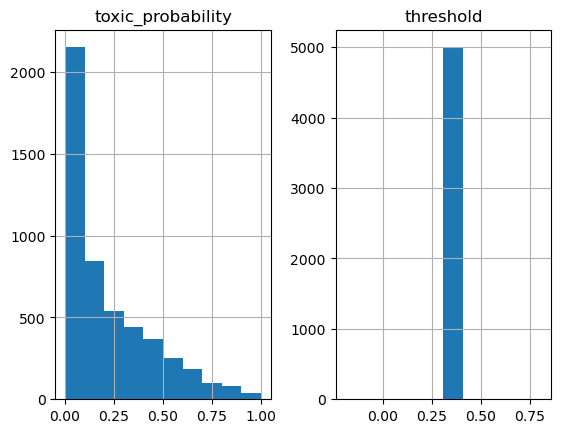

In [78]:
df_nontoxic_final.hist()


  filename prediction  toxic_probability  threshold              source_folder
0  000.jpg      TOXIC           0.950997       0.31  tpc-imgs/toxic_images/000
1  001.jpg      TOXIC           0.920122       0.31  tpc-imgs/toxic_images/000
2  002.jpg      TOXIC           0.702426       0.31  tpc-imgs/toxic_images/000
3  003.jpg      TOXIC           0.870566       0.31  tpc-imgs/toxic_images/000
4  004.jpg      TOXIC           0.974457       0.31  tpc-imgs/toxic_images/000


array([[<Axes: title={'center': 'toxic_probability'}>,
        <Axes: title={'center': 'threshold'}>]], dtype=object)

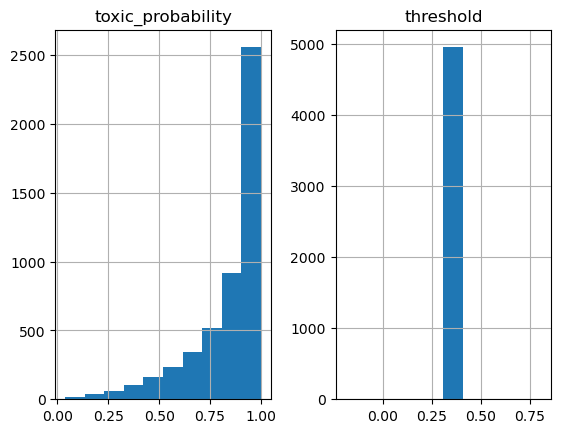

In [82]:
print(df_toxic_final.head())
df_toxic_final.hist()

In [60]:
df_toxic_final.prediction.value_counts()

prediction
TOXIC        4878
Non-Toxic      75
Name: count, dtype: int64

In [62]:
75/4878

0.015375153751537515

In [63]:
1552/3447

0.4502465912387583

In [65]:
4878+3447+75+1552

9952

In [66]:
(1552+75)/9952

0.1634847266881029

# 4. Analyzing Results

In [74]:
#merge the dataframes into one
merged_predictions = pd.concat([df_toxic_final, df_nontoxic_final], ignore_index=True)

In [83]:
#create new column to merge on with features dataframe
merged_predictions["path"] = merged_predictions.apply(lambda row: os.path.join(row["source_folder"], row["filename"]), axis=1)

In [68]:
#import original dataframe with species name
plant_features=pd.read_csv('All_Plants_Features.csv.')

In [87]:
#normalize both paths to match
plant_features["path"] = plant_features["path"].apply(os.path.normpath)
merged_predictions["path"] = merged_predictions["path"].apply(os.path.normpath)

#merge dataframes on path column
merged_final = plant_features.merge(merged_predictions[["path", "prediction", "toxic_probability", "threshold"]],
    on="path", how="left")


In [93]:
merged_final["correct_prediction"] = (
    (merged_final["toxicity"] == 1) & (merged_final["prediction"] == "TOXIC")
) | (
    (merged_final["toxicity"] == 0) & (merged_final["prediction"] == "Non-Toxic")
)

In [94]:
merged_final.head()

,class_id,slang,scientific_name,toxicity,width,height,orientation,brightness,contrast,hue,saturation,path,filename,source_folder,prediction,toxic_probability,threshold,correct_prediction
0,0,Virginia creeper,Parthenocissus quinquefolia,0,335,500,portrait,0.082785,0.195098,0.081668,0.158307,tpc-imgs\nontoxic_images\000\000.jpg,000.jpg,tpc-imgs\nontoxic_images\000\,Non-Toxic,0.085745,0.28,True
1,0,Virginia creeper,Parthenocissus quinquefolia,0,447,500,portrait,0.688486,0.194105,0.525180,0.412088,tpc-imgs\nontoxic_images\000\001.jpg,001.jpg,tpc-imgs\nontoxic_images\000\,TOXIC,0.323895,0.28,False
2,0,Virginia creeper,Parthenocissus quinquefolia,0,333,500,portrait,0.501910,0.125857,0.549203,0.653836,tpc-imgs\nontoxic_images\000\002.jpg,002.jpg,tpc-imgs\nontoxic_images\000\,Non-Toxic,0.272221,0.28,True
3,0,Virginia creeper,Parthenocissus quinquefolia,0,333,500,portrait,0.619444,0.171032,0.524528,0.494764,tpc-imgs\nontoxic_images\000\003.jpg,003.jpg,tpc-imgs\nontoxic_images\000\,TOXIC,0.404992,0.28,False
4,0,Virginia creeper,Parthenocissus quinquefolia,0,375,500,portrait,0.577980,0.234796,0.232493,0.210950,tpc-imgs\nontoxic_images\000\004.jpg,004.jpg,tpc-imgs\nontoxic_images\000\,Non-Toxic,0.002516,0.28,True


In [101]:
accuracy_by_species = (
    merged_final.groupby("slang")["correct_prediction"]
      .mean()
      .reset_index()
      .rename(columns={"correct_prediction": "accuracy"})
)
print(accuracy_by_species)

                slang  accuracy
0            Bear Oak  0.764000
1            Boxelder  0.588000
2  Eastern Poison Ivy  0.982000
3  Eastern Poison Oak  0.980084
4      Fragrant Sumac  0.542543
5  Jack-in-the-pulpit  0.854000
6        Poison Sumac  0.992993
7    Virginia creeper  0.699000
8  Western Poison Ivy  0.985000
9  Western Poison Oak  0.984000


In [98]:
import seaborn as sns

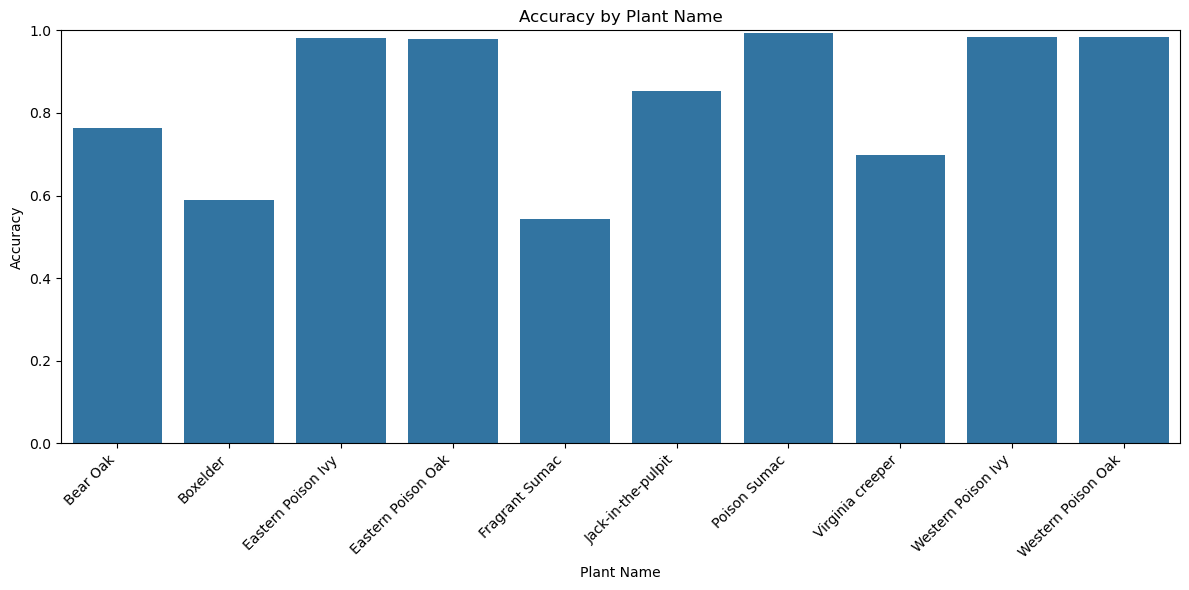

In [104]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=accuracy_by_species,
    x="slang",
    y="accuracy")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Accuracy by Plant Name")
plt.ylabel("Accuracy")
plt.xlabel("Plant Name")
plt.tight_layout()
plt.show()